In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("tested.csv")

# Display first 5 rows
print(df.head())

In [20]:
df = pd.read_csv("tested.csv")

In [21]:
 num_cols = ['CGPA','AttendancePercent','AptitudeTestScore', 'CodingTestScore', 'SoftSkillsRating', 'Salary Package']

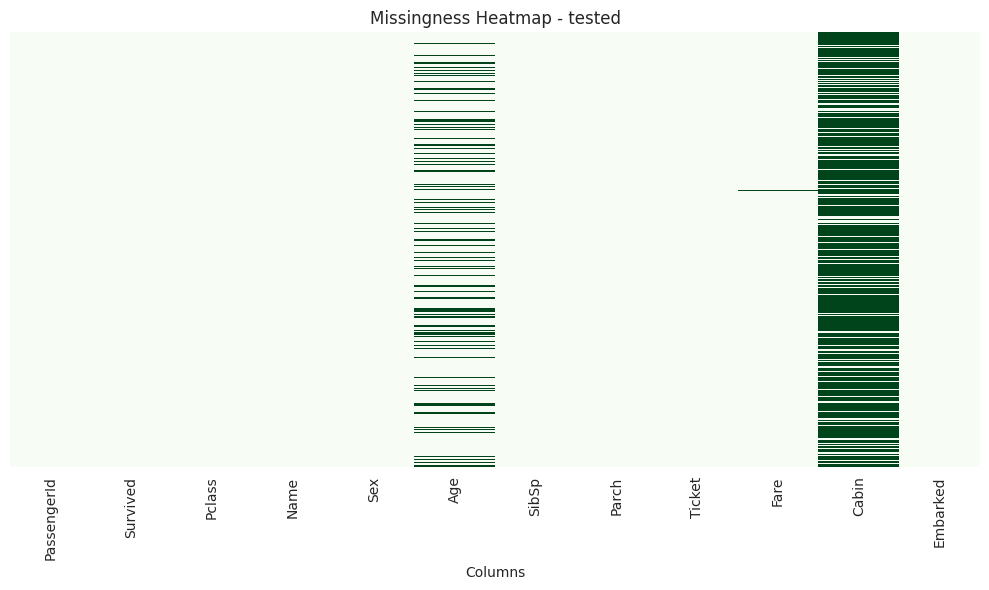

In [22]:
fig1 = plt.figure(figsize=(10, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="Greens",
    yticklabels=False
)

plt.title("Missingness Heatmap - tested")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

Numeric columns:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


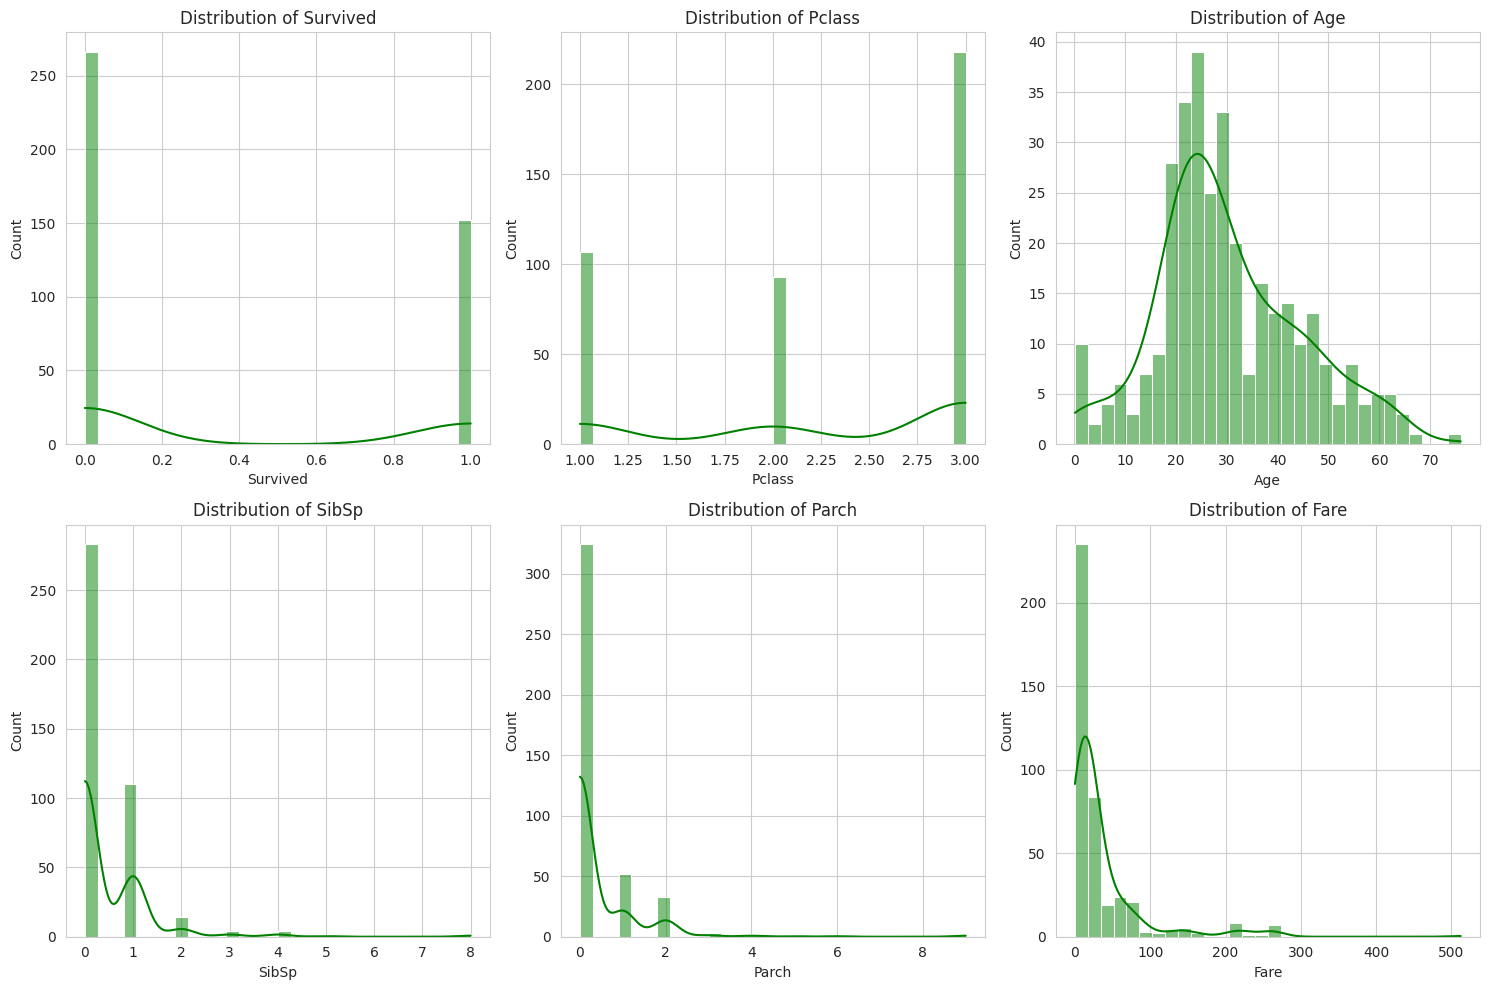

In [26]:
import math

# Select numeric columns
num_cols = df.select_dtypes(include='number').columns.tolist()

# Remove PassengerId because it is only an ID
if 'PassengerId' in num_cols:
    num_cols.remove('PassengerId')

print("Numeric columns:")
print(num_cols)

# Number of columns in each row
ncols = 3

# Calculate required number of rows
nrows = math.ceil(len(num_cols) / ncols)

# Create plots
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 5 * nrows)
)

# Convert axes to a 1D array
axes = np.array(axes).flatten()

# Create histogram for each column
for i, col in enumerate(num_cols):

    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True,
        ax=axes[i],
        color='green'
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide unused plots
for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages("EDA_Report.pdf")

for fig in [fig1, fig2]:
    pdf.savefig(fig)

pdf.close()

print("EDA_Report.pdf created successfully!")

EDA_Report.pdf created successfully!


In [29]:
from google.colab import files

files.download("EDA_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>